In [1]:
from __future__ import annotations
import os
import re
import bw2data
from bw2data import get_activity
from dataclasses import dataclass
from typing import Dict, Iterable, Literal, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# activate the bw project
#bw2data.projects.set_current("ei311")

In [4]:
import sys
sys.path.append('../../utils/') 
from dpLCIA import * 

## input file needed: 
- dynLCI_file_path: dynamic LCI 
- ghg_dir:  all FaIR metrics, with uncertainty, we calc here, not via BW2 

In [5]:
hydro_files_2030 = {
    ("SSP1-19", 2030): "../dp-LCI_output/hydro_dpLCI_v2_reservoir/market_for_electricity_hydro_high_voltage_CA-QC_SSP1-VLLO_2030.xlsx",
    ("SSP5-85", 2030): "../dp-LCI_output/hydro_dpLCI_v2_reservoir/market_for_electricity_hydro_high_voltage_CA-QC_SSP5-H_2030.xlsx",
}

hydro_files_2050 = {
    ("SSP1-19", 2050): "../dp-LCI_output/hydro_dpLCI_v2_reservoir/dateshifted/market_for_electricity_hydro_high_voltage_CA-QC_SSP1-VLLO_2050.xlsx",
    ("SSP5-85", 2050): "../dp-LCI_output/hydro_dpLCI_v2_reservoir/dateshifted/market_for_electricity_hydro_high_voltage_CA-QC_SSP5-H_2050.xlsx",
}

ghg_dir = "../../../dpLCIA/FaIR_dpCFs/output/metrics"   # directory containing all CO2/CH4/N2O Excel files

# RF is the radiative forcing metric to use
metric = "rf"   # or "agwp"  

In [6]:
results_rf = compute_dynamic_lcia_for_scenarios(
    elec_files=hydro_files_2030,
    ghg_dir=ghg_dir,
    metric="rf",    
)

print(f"Scenarios computed: {list(results_rf.keys())}")

Scenarios computed: [('SSP1-19', 2030), ('SSP5-85', 2030)]


In [7]:
results_agwp = compute_dynamic_lcia_for_scenarios(
    elec_files=hydro_files_2030,
    ghg_dir=ghg_dir,
    metric="agwp",  
)

print(f"Scenarios computed: {list(results_agwp.keys())}")

Scenarios computed: [('SSP1-19', 2030), ('SSP5-85', 2030)]


#### now compute 2050 LCIA, make sure corrected hydro 2050 path

In [8]:
results_rf_2050 = compute_dynamic_lcia_for_scenarios(
    elec_files=hydro_files_2050,
    ghg_dir=ghg_dir,
    metric="rf",    
)
#print(f"Scenarios computed: {list(results_rf.keys())}") # wrong print out 

results_agwp_2050 = compute_dynamic_lcia_for_scenarios(
    elec_files=hydro_files_2050,
    ghg_dir=ghg_dir,
    metric="agwp",  
)
#print(f"Scenarios computed: {list(results_agwp.keys())}")

Scenarios computed: [('SSP1-19', 2030), ('SSP5-85', 2030)]
Scenarios computed: [('SSP1-19', 2030), ('SSP5-85', 2030)]


In [9]:
### saving the results as pickle
from pathlib import Path
import pickle

out_dir =  Path.cwd() / "results_updated_CO2CH4"
out_dir.mkdir(exist_ok=True)

# 1) Pickles (full objects, preserves DatetimeIndex/DataFrames)
rf_pkl   = out_dir / "results_rf_2030.pkl"
agwp_pkl = out_dir / "results_agwp_2030.pkl"

rf_pkl_2050   = out_dir / "results_rf_2050.pkl"
agwp_pkl_2050 = out_dir / "results_agwp_2050.pkl"


# save 2030 
with open(rf_pkl, "wb") as f:
    pickle.dump(results_rf, f, protocol=pickle.HIGHEST_PROTOCOL)

with open(agwp_pkl, "wb") as f:
    pickle.dump(results_agwp, f, protocol=pickle.HIGHEST_PROTOCOL)



### save 2050 
with open(rf_pkl_2050, "wb") as f:
    pickle.dump(results_rf_2050, f, protocol=pickle.HIGHEST_PROTOCOL)

with open(agwp_pkl_2050, "wb") as f:
    pickle.dump(results_agwp_2050, f, protocol=pickle.HIGHEST_PROTOCOL)



### plot 

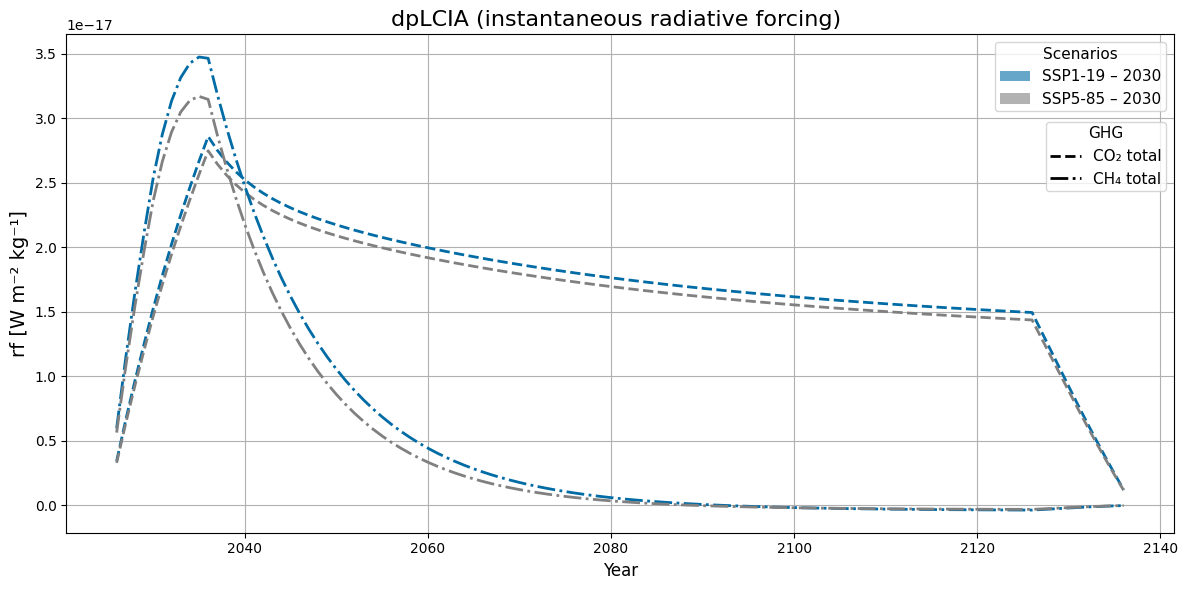

In [12]:
plot_multi_scenario_split_each_ghg_totalscore(
    results=results_rf,
    metric="rf",
    gases_to_plot = [  'co2_total', 'ch4_total' ] , #'co2_biogenic',   "ch4_non_fossil"], #
    plot_uncertainty= False,
    figsize  = (12, 6),
)

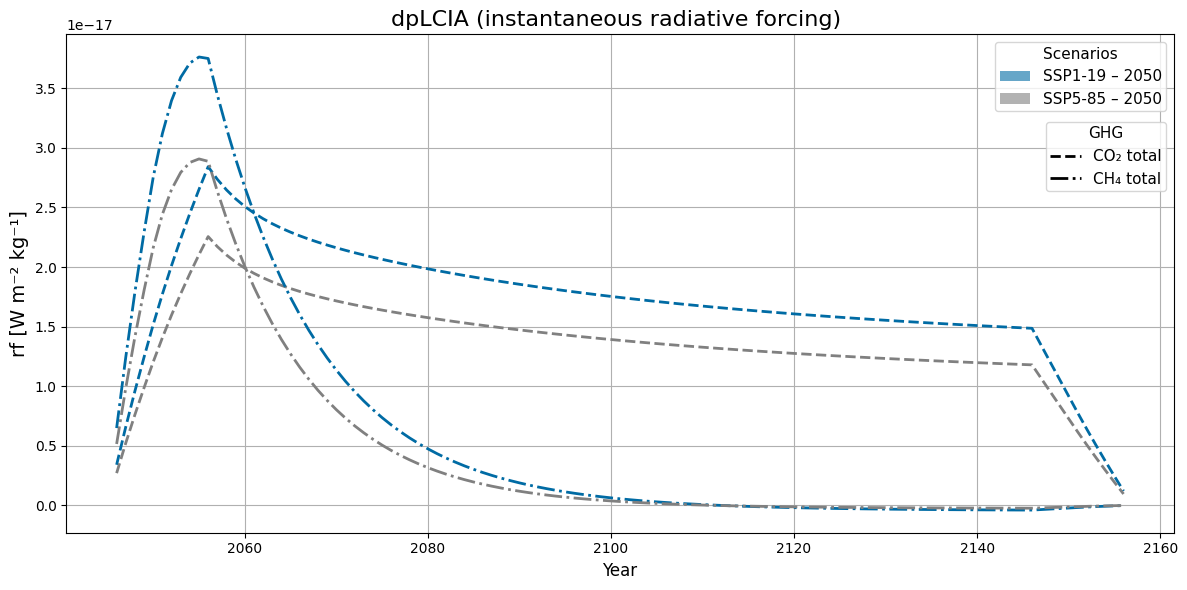

In [49]:
plot_multi_scenario_split_each_ghg_totalscore(
    results=results_rf,
    metric="rf",
    gases_to_plot = [  'co2_total', 'ch4_total' ] , #'co2_biogenic',   "ch4_non_fossil"], #
    plot_uncertainty= False,
    figsize  = (12, 6),
)

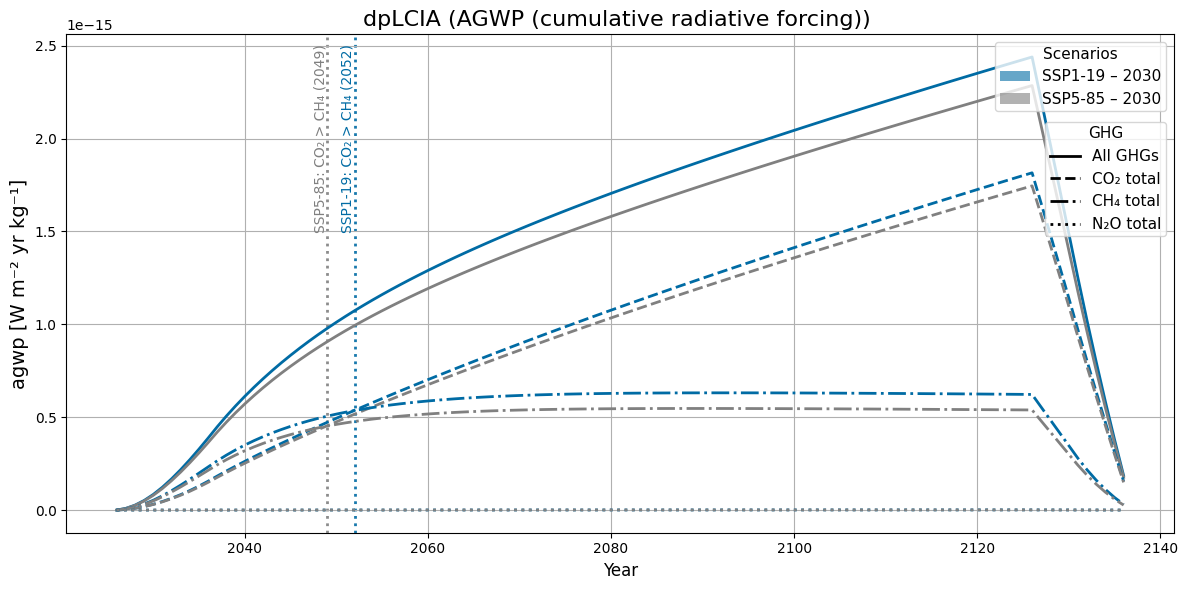

In [13]:
plot_multi_scenario_split_each_ghg_totalscore(
    results=results_agwp,
    metric="agwp",
    plot_uncertainty= False, 
    figsize  = (12, 6),
)


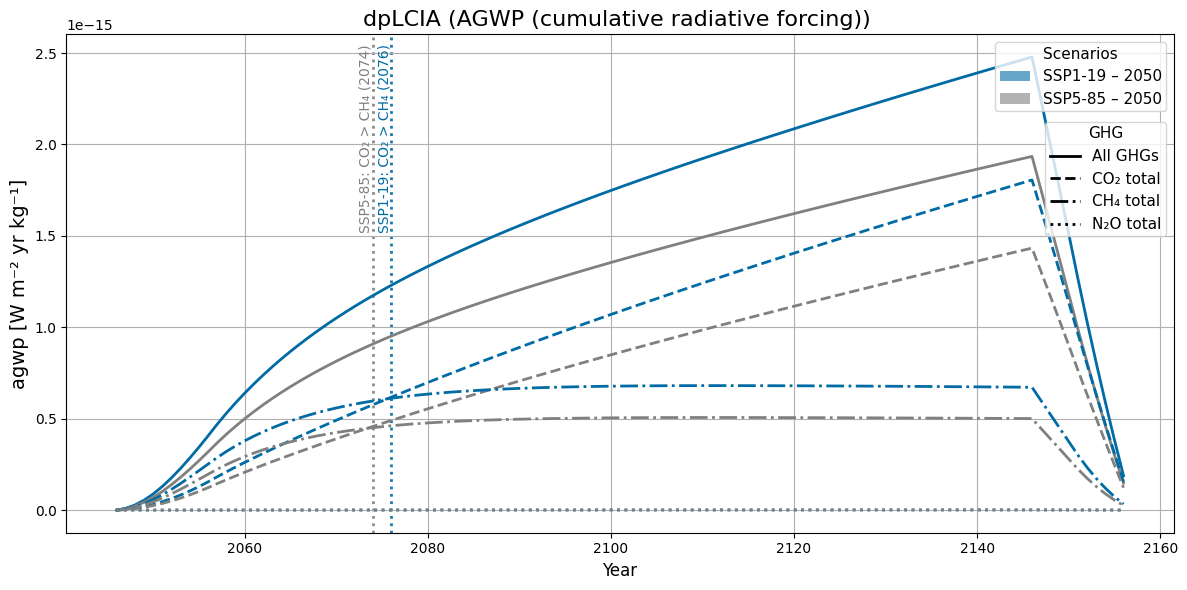

In [50]:
plot_multi_scenario_split_each_ghg_totalscore(
    results=results_agwp,
    metric="agwp",
    plot_uncertainty= False, 
    figsize  = (12, 6),
)


### single gas sub-cat, w/h uncertainty 

Gas options:  'CO2', 'CH4', 'N2O', 'ALL'
metric options: 'rf', 'agwp'
Subcategory options only for a single GHG (not for ALL): 'co2_total', 'ch4_total', 'n2o_total', 
 co2_other_negative, co2_biogenic, co2_fossil_positive, ch4_fossil, ch4_non_fossil, ch4_biomass


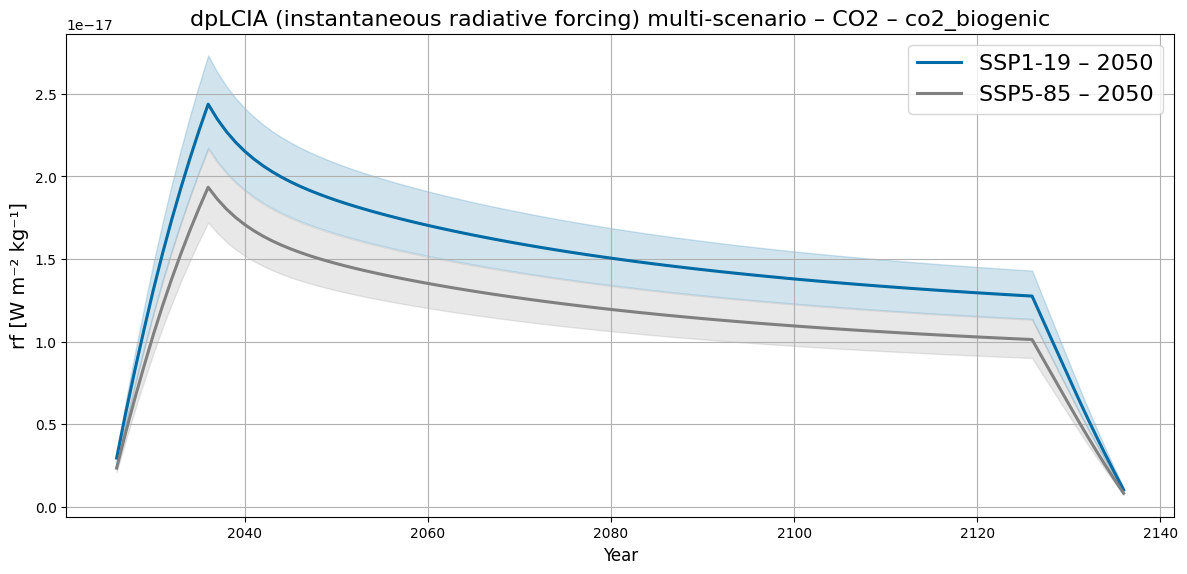

In [15]:
plot_multi_scenario_bands(
    results = results,
    metric = metric, 
    gas_to_plot = "CO2",
    subcat = "co2_biogenic") 

Gas options:  'CO2', 'CH4', 'N2O', 'ALL'
metric options: 'rf', 'agwp'
Subcategory options only for a single GHG (not for ALL): 'co2_total', 'ch4_total', 'n2o_total', 
 co2_other_negative, co2_biogenic, co2_fossil_positive, ch4_fossil, ch4_non_fossil, ch4_biomass


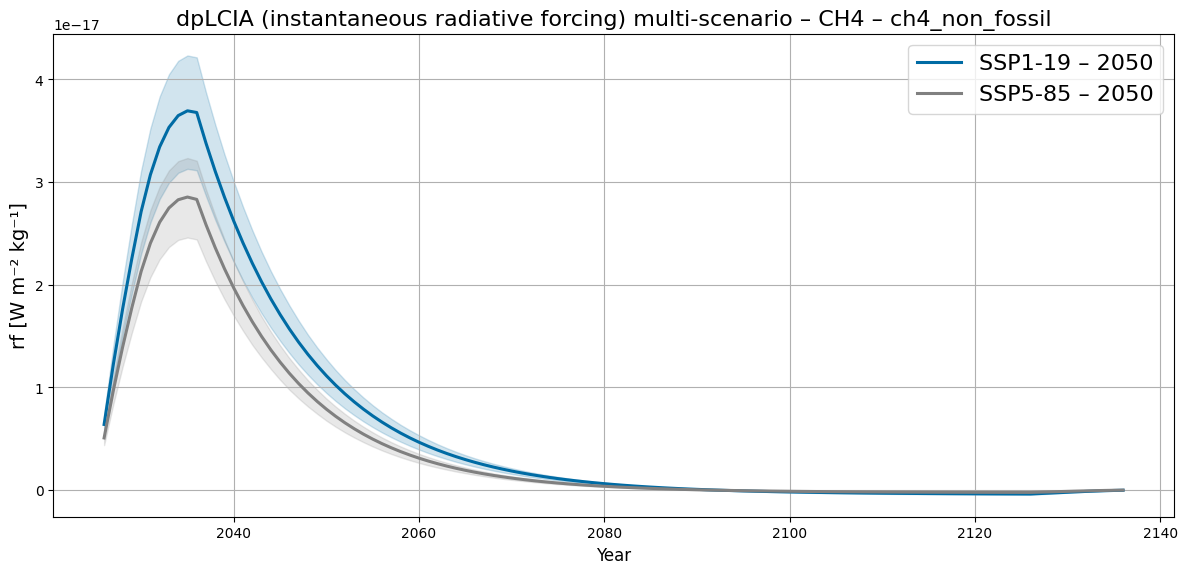

In [19]:
plot_multi_scenario_bands(
    results = results,
    metric = metric, 
    gas_to_plot = "CH4",
    subcat = "ch4_non_fossil") 

Gas options:  'CO2', 'CH4', 'N2O', 'ALL'
metric options: 'rf', 'agwp'
Subcategory options only for a single GHG (not for ALL): 'co2_total', 'ch4_total', 'n2o_total', 
 co2_other_negative, co2_biogenic, co2_fossil_positive, ch4_fossil, ch4_non_fossil, ch4_biomass


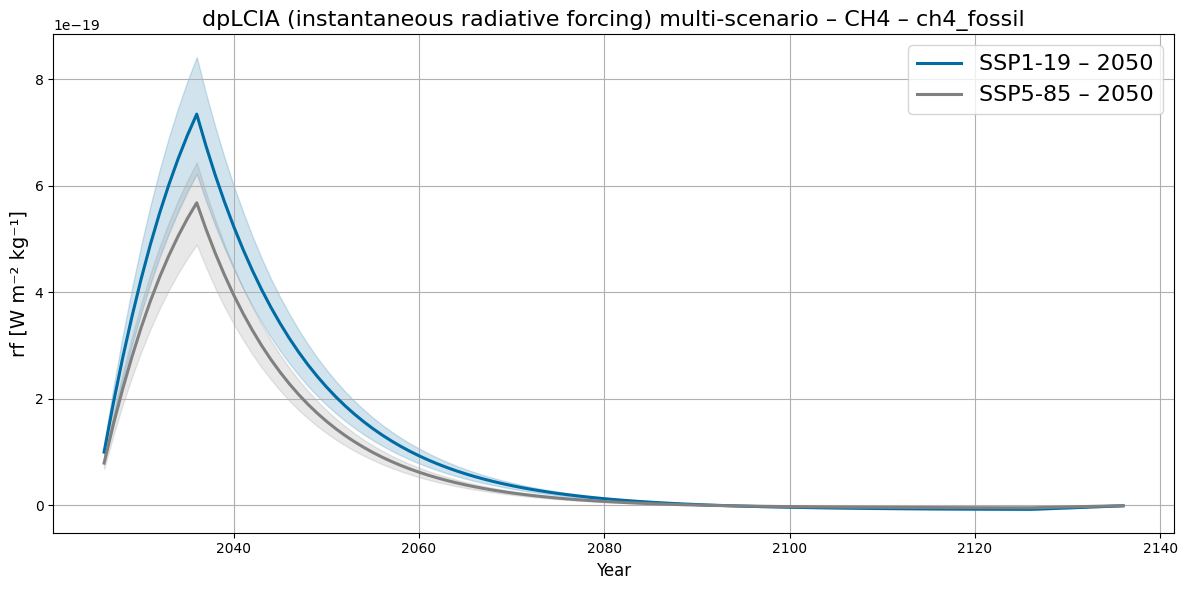

In [20]:
plot_multi_scenario_bands(
    results = results,
    metric = metric, 
    gas_to_plot = "CH4",
    subcat = "ch4_fossil") 

#### some test code

##### BW2 mapping

#####  start dpLCIA

##### compute dynamic LCIA per subtype (central + 5–95 % band)

###  ONE scn/MY dplcia and plot 

In [32]:
metric = 'rf'

one_file_path =  "dp-LCI_output/hydro_dpLCI_v2_reservoir/dateshifted/market_for_electricity_hydro_high_voltage_CA-QC_SSP5-H_2050.xlsx"
 
out = compute_dynamic_lcia_by_category(
    elec_path=one_file_path,
    ghg_dir=ghg_dir,
    metric=metric,
)

eval_years = out["eval_years"]
central    = out["central"]
band       = out["band"]
flow_info  = out["flow_info"]
ssp_ = out["SSP"]
MY_ = out["ModelYear"] 

#print("=== DONE: dynamic LCIA computed ===")
print("central columns:", central.columns.tolist())
print("band columns (lower):", band["lower"].columns.tolist())
print("band columns (upper):", band["upper"].columns.tolist())


central columns: ['ch4_biomass', 'ch4_fossil', 'ch4_non_fossil', 'ch4_other', 'co2_biogenic', 'co2_fossil_positive', 'co2_other_negative', 'n2o_all', 'co2_total', 'ch4_total', 'n2o_total', 'all_ghg']
band columns (lower): ['ch4_biomass', 'ch4_fossil', 'ch4_non_fossil', 'ch4_other', 'co2_biogenic', 'co2_fossil_positive', 'co2_other_negative', 'n2o_all', 'co2_total', 'ch4_total', 'n2o_total', 'all_ghg']
band columns (upper): ['ch4_biomass', 'ch4_fossil', 'ch4_non_fossil', 'ch4_other', 'co2_biogenic', 'co2_fossil_positive', 'co2_other_negative', 'n2o_all', 'co2_total', 'ch4_total', 'n2o_total', 'all_ghg']


In [33]:
central["co2_biogenic"]

2046-01-01    2.335026e-18
2047-01-01    4.517167e-18
2048-01-01    6.574639e-18
2049-01-01    8.529893e-18
2050-01-01    1.040081e-17
                  ...     
2152-01-01    4.312886e-18
2153-01-01    3.397515e-18
2154-01-01    2.508630e-18
2155-01-01    1.646141e-18
2156-01-01    8.099599e-19
Freq: YS-JAN, Name: co2_biogenic, Length: 111, dtype: float64

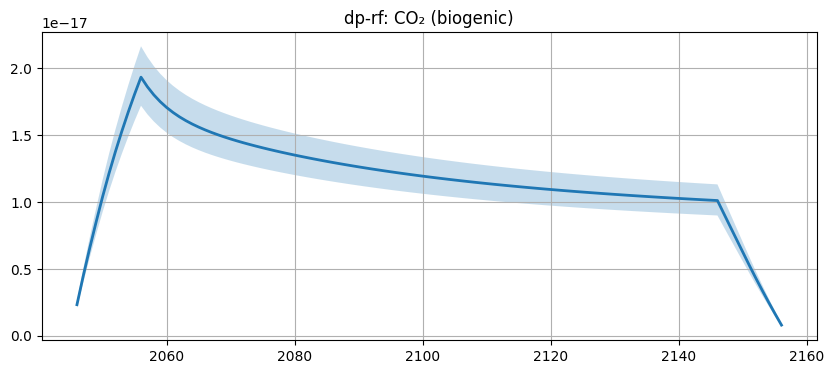

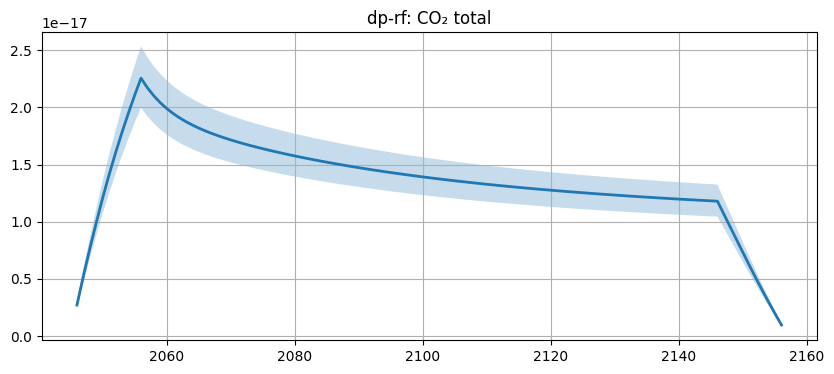

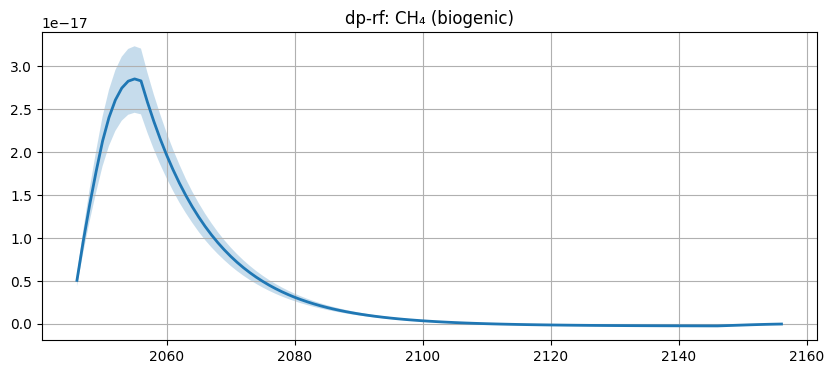

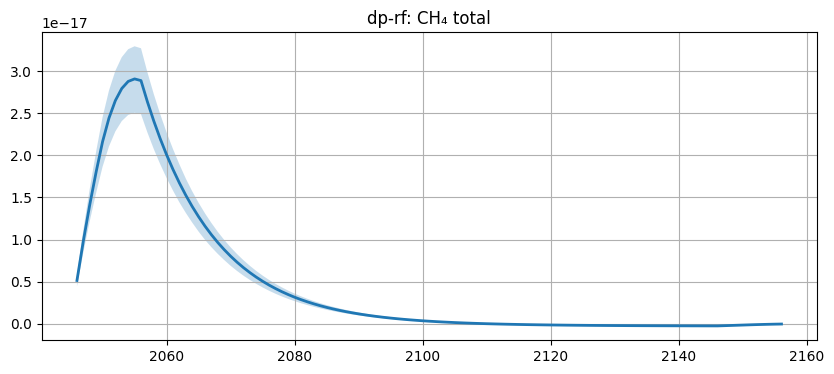

In [35]:
# -----------------------------------------------------------
# PLOTTING HELPERS
# -----------------------------------------------------------
def quick_plot(series, lower, upper, title):
    plt.figure(figsize=(10,4))
    plt.fill_between(eval_years, lower, upper, alpha=0.25)
    plt.plot(eval_years, series, lw=2)
    plt.title(title)
    plt.grid(True)
    plt.show()


# 1. CO2 category 
if "co2_biogenic" in central.columns:
    quick_plot(
        central["co2_biogenic"],
        band["lower"]["co2_biogenic"],
        band["upper"]["co2_biogenic"],
        f"dp-{metric}: CO₂ (biogenic)"
    )
else:
    print("Not found.")


# 2. CO2 total
quick_plot(
    central["co2_total"],
    band["lower"]["co2_total"],
    band["upper"]["co2_total"],
    f"dp-{metric}: CO₂ total"
)

# -----------------------------------------------------------
# 3. CH4 total
# -----------------------------------------------------------

if "ch4_non_fossil" in central.columns:
    quick_plot(
        central["ch4_non_fossil"],
        band["lower"]["ch4_non_fossil"],
        band["upper"]["ch4_non_fossil"],
        f"dp-{metric}: CH₄ (biogenic)"
    )
else:
    print("Not found.")


quick_plot(
    central["ch4_total"],
    band["lower"]["ch4_total"],
    band["upper"]["ch4_total"],
    f"dp-{metric}: CH₄ total"
)


